# **Machine Learning II Final Project: Speech Emotion Recognition (RAVDESS)**

**Authors:**
Lam Tran,
Kevin Wang,
Jason Clark,
Yining Mao

**Project goal.** Many real-world systems such as virtual assistants, customer service bots, and healthcare monitoring tools cannot naturally understand human emotions during speech interactions. In this project we build a speech emotion recognition system that predicts emotions directly from audio recordings, using the **RAVDESS Emotional Speech Audio Dataset**.

Dataset: https://www.kaggle.com/datasets/uwrfkaggler/ravdess-emotional-speech-audio


**Setup**

In [45]:
# Core data libraries
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
import seaborn as sns

# Audio
import librosa
import librosa.display

# Filesystem helpers
import os
import sys
import glob
import subprocess
from pathlib import Path

# Traditional ML
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

# Deep learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# Misc
import warnings
warnings.filterwarnings("ignore")

# Reproducibility — fixing seeds so train/test splits and model weights
# are consistent each time we run the notebook
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Plot style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

IS_COLAB = "google.colab" in sys.modules
print("Libraries imported successfully.")
print("TensorFlow version:", tf.__version__)
print("Librosa version:", librosa.__version__)
print("Environment:", "Google Colab" if IS_COLAB else "local")

Libraries imported successfully.
TensorFlow version: 2.20.0
Librosa version: 0.11.0
Environment: local


**Load our Kaggle credentials**

- **Colab:** mounts Google Drive and copies the `kaggle.json` token stored at `MyDrive/ml2/kaggle.json`.
- **Local:** expects `kaggle.json` to already exist at `~/.kaggle/kaggle.json` (the standard location). Download it from [kaggle.com/settings](https://www.kaggle.com/settings) → API → Create New Token, then `pip install kaggle` if you haven't already.

In [46]:
import shutil

# Install kaggle if not already present
try:
    import kaggle  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "kaggle", "-q"], check=True)

if IS_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_KAGGLE_JSON = '/content/drive/MyDrive/ml2/kaggle.json'
    os.makedirs('/root/.kaggle', exist_ok=True)
    shutil.copy(DRIVE_KAGGLE_JSON, '/root/.kaggle/kaggle.json')
    os.chmod('/root/.kaggle/kaggle.json', 0o600)
    print("Colab: Drive mounted and Kaggle credentials loaded.")
else:
    kaggle_json = os.path.expanduser("~/.kaggle/kaggle.json")
    if not os.path.exists(kaggle_json):
        raise FileNotFoundError(
            f"Kaggle credentials not found at {kaggle_json}\n"
            "Download kaggle.json from https://www.kaggle.com/settings → API → Create New Token"
        )
    print(f"Local: Kaggle credentials found at {kaggle_json}")

Local: Kaggle credentials found at /Users/kevinwang/.kaggle/kaggle.json


**Download and unzip the RAVDESS dataset**

Now that the Kaggle CLI is authenticated, we pull the RAVDESS dataset directly into Colab's local storage at `/content/data/`. We wrap both the download and the unzip in `if`-checks so that re-running the cell is cheap: if the zip already exists we skip the download, and if the `.wav` files are already extracted we skip the unzip. Finally, we walk the extracted folder to find where the `Actor_*` subdirectories actually live and set `DATA_DIR` to that path, which the rest of the notebook will use to read files.

In [47]:
import zipfile

KAGGLE_DATASET = "uwrfkaggler/ravdess-emotional-speech-audio"
DATA_ROOT = Path("/content/data") if IS_COLAB else Path("./data")
EXTRACT_DIR = DATA_ROOT / "ravdess"
DATA_ROOT.mkdir(parents=True, exist_ok=True)
EXTRACT_DIR.mkdir(parents=True, exist_ok=True)

existing_zips = list(DATA_ROOT.glob("*.zip"))
if not existing_zips:
    print(f"Downloading {KAGGLE_DATASET} ...")
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", KAGGLE_DATASET, "-p", str(DATA_ROOT), "--force"],
        check=True,
    )
    existing_zips = list(DATA_ROOT.glob("*.zip"))

zip_path = existing_zips[0]
print(f"Zip located at: {zip_path}")

if not any(EXTRACT_DIR.rglob("Actor_*")):
    print(f"Extracting to {EXTRACT_DIR} ...")
    with zipfile.ZipFile(zip_path, "r") as z:
        z.extractall(EXTRACT_DIR)
else:
    print(f"Files already extracted in {EXTRACT_DIR}, skipping unzip.")

# Find the folder that actually contains the Actor_* subdirectories
actor_dirs = list(EXTRACT_DIR.rglob("Actor_*"))
if not actor_dirs:
    raise RuntimeError(f"Could not find Actor_* folders under {EXTRACT_DIR}")
DATA_DIR = str(actor_dirs[0].parent)
print(f"\nDATA_DIR set to: {DATA_DIR}")
print(f"Found {len(actor_dirs)} actor folders.")

Zip located at: data/ravdess-emotional-speech-audio.zip
Files already extracted in data/ravdess, skipping unzip.

DATA_DIR set to: data/ravdess
Found 48 actor folders.


**Load and organize data**

The RAVDESS dataset stores each recording as a `.wav` file inside actor-specific folders (e.g., `Actor_01/`, `Actor_02/`, …). The emotion label is encoded in the filename rather than provided in a separate CSV, which is unusual but common for audio datasets.

A typical filename looks like:

```
03-01-05-01-02-01-12.wav
```

Each of the seven hyphen-separated parts translates into something:

| Position | Meaning                | Example  |
|----------|------------------------|----------|
| 1        | Modality (03 = audio)  | 03       |
| 2        | Vocal channel          | 01 = speech |
| 3        | **Emotion**            | 05 = angry  |
| 4        | Emotional intensity    | 01 = normal |
| 5        | Statement              | 02       |
| 6        | Repetition             | 01       |
| 7        | Actor ID (odd = male, even = female) | 12 |

We only need the **emotion code** and the **actor ID**, but parsing all of it now makes the dataframe more flexible for downstream experiments.

In [48]:
print(f"Using DATA_DIR: {DATA_DIR}")

Using DATA_DIR: data/ravdess


In [49]:
# Mapping from RAVDESS emotion code -> human-readable label
EMOTION_MAP = {
    "01": "neutral",
    "02": "calm",
    "03": "happy",
    "04": "sad",
    "05": "angry",
    "06": "fearful",
    "07": "disgust",
    "08": "surprised",
}

def parse_ravdess_filename(filepath):
    """Pull the emotion code, emotion label, and actor ID out of a RAVDESS .wav filename.

    Returns a dict with keys: emotion_code, emotion_label, actor_id.
    Returns None if the filename doesn't follow the RAVDESS pattern.
    """
    name = Path(filepath).stem  # filename without .wav
    parts = name.split("-")
    if len(parts) != 7:
        return None
    emotion_code = parts[2]
    actor_id = parts[6]
    emotion_label = EMOTION_MAP.get(emotion_code)
    if emotion_label is None:
        return None
    return {
        "emotion_code": emotion_code,
        "emotion_label": emotion_label,
        "actor_id": actor_id,
    }

# Recursively find every .wav file under DATA_DIR
wav_paths = sorted(glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True))
print(f"Found {len(wav_paths)} .wav files in {DATA_DIR}")

# Build the dataframe
rows = []
for p in wav_paths:
    parsed = parse_ravdess_filename(p)
    if parsed is None:
        rows.append({
            "file_path": p,
            "emotion_code": None,
            "emotion_label": None,
            "actor_id": None,
        })
        continue
    rows.append({"file_path": p, **parsed})

df = pd.DataFrame(rows)
print(f"\nRaw dataframe shape: {df.shape}")


# The Kaggle zip extracts the same files into two parallel folders
# (Actor_xx/ at the root AND audio_speech_actors_01-24/Actor_xx/), so every
# clip shows up twice. We keep just the first occurrence of each filename.
df["_basename"] = df["file_path"].apply(os.path.basename)
n_before = len(df)
df = df.drop_duplicates(subset="_basename", keep="first").drop(columns="_basename").reset_index(drop=True)
print(f"Dropped {n_before - len(df)} duplicate rows. Final shape: {df.shape}")

df.head()

Found 2880 .wav files in data/ravdess

Raw dataframe shape: (2880, 4)
Dropped 1440 duplicate rows. Final shape: (1440, 4)


,file_path,emotion_code,emotion_label,actor_id
0,data/ravdess/Actor_01/03-01-01-01-01-01-01.wav,01,neutral,01
1,data/ravdess/Actor_01/03-01-01-01-01-02-01.wav,01,neutral,01
2,data/ravdess/Actor_01/03-01-01-01-02-01-01.wav,01,neutral,01
3,data/ravdess/Actor_01/03-01-01-01-02-02-01.wav,01,neutral,01
4,data/ravdess/Actor_01/03-01-02-01-01-01-01.wav,02,calm,01


We print the dataframe shape and the first few rows to verify it looks right. We should see one row per `.wav` file with the parsed emotion and actor columns filled in.

In [50]:
# Quick check
print("Columns:", list(df.columns))
print("\nDtypes:\n", df.dtypes)
print("\nFirst 5 rows:")



Columns: ['file_path', 'emotion_code', 'emotion_label', 'actor_id']

Dtypes:
 file_path        object
emotion_code     object
emotion_label    object
actor_id         object
dtype: object

First 5 rows:


In [51]:
# How many files share the same filename?
import collections
names = [os.path.basename(p) for p in wav_paths]
counts = collections.Counter(names)
dupes = {n: c for n, c in counts.items() if c > 1}
print(f"Unique filenames: {len(counts)}")
print(f"Filenames appearing >1 time: {len(dupes)}")
if dupes:
    sample_name = next(iter(dupes))
    print(f"\nExample of a duplicated filename: {sample_name}")
    print("All paths for that file:")
    for p in wav_paths:
        if os.path.basename(p) == sample_name:
            print("  ", p)

Unique filenames: 1440
Filenames appearing >1 time: 1440

Example of a duplicated filename: 03-01-01-01-01-01-01.wav
All paths for that file:
   data/ravdess/Actor_01/03-01-01-01-01-01-01.wav
   data/ravdess/audio_speech_actors_01-24/Actor_01/03-01-01-01-01-01-01.wav


**Data cleaning and validation**

Before training a model, we want to make sure the dataset is actually clean and consistent.

Here are the validations we are checking

1. Are all files actually `.wav` files?
2. Do all filenames follow the expected RAVDESS 7-part structure?
3. Are there any invalid emotion codes (i.e., codes not in 01–08)?
4. Are there missing labels (rows where parsing failed)?
5. Are there duplicate file paths?
6. Can librosa actually load every file without errors?
7. Does every actor have the expected number of recordings (60 per actor for RAVDESS speech)?
8. Are there any nearly-silent clips that would produce useless features?
9. Later, after feature extraction, we will also check for `NaN` or `inf` feature values.

In [52]:
# every file path ends with .wav
non_wav = df[~df["file_path"].str.lower().str.endswith(".wav")]
print(f"Files that are NOT .wav: {len(non_wav)}")


Files that are NOT .wav: 0


In [53]:
#  filenames that don't follow the RAVDESS 7-part structure
# These are the rows where parse_ravdess_filename returned None (emotion_code is NaN).
bad_format = df[df["emotion_code"].isna()]
print(f"Filenames not following RAVDESS structure: {len(bad_format)}")
if len(bad_format) > 0:
    print("Examples:")
    print(bad_format["file_path"].head().tolist())


Filenames not following RAVDESS structure: 0


In [54]:
# invalid emotion codes
# Any code that exists in the data but is NOT in our known mapping.
valid_codes = set(EMOTION_MAP.keys())
invalid_codes = df.dropna(subset=["emotion_code"])
invalid_codes = invalid_codes[~invalid_codes["emotion_code"].isin(valid_codes)]
print(f"Rows with invalid emotion codes: {len(invalid_codes)}")


Rows with invalid emotion codes: 0


In [55]:
# missing labels
missing_label = df[df["emotion_label"].isna()]
print(f"Rows with missing emotion_label: {len(missing_label)}")


Rows with missing emotion_label: 0


In [56]:
# duplicate file paths
dupes = df[df.duplicated(subset=["file_path"], keep=False)]
print(f"Duplicate file paths: {len(dupes)}")


Duplicate file paths: 0


In [57]:
# Each RAVDESS speech actor should have 60 recordings (4 statements × 2 reps
# × 8 emotions, minus the 4 missing "strong neutral" combos -> 60 per actor).
per_actor = df.groupby("actor_id").size().sort_index()
print(per_actor)
print(f"\nActors with != 60 files: {(per_actor != 60).sum()}")

actor_id
01    60
02    60
03    60
04    60
05    60
06    60
07    60
08    60
09    60
10    60
11    60
12    60
13    60
14    60
15    60
16    60
17    60
18    60
19    60
20    60
21    60
22    60
23    60
24    60
dtype: int64

Actors with != 60 files: 0


In [58]:
import numpy as np
# Sample a few files; if you want to be exhaustive, loop over all of df.
silent = []
for p in df["file_path"].sample(min(100, len(df)), random_state=42):
    y, sr = librosa.load(p, sr=22050)
    rms = np.sqrt(np.mean(y**2))
    if rms < 1e-3:        # nearly inaudible
        silent.append((p, rms))
print(f"Suspiciously silent clips in sample: {len(silent)}")

Suspiciously silent clips in sample: 0


We now drop any rows that failed the structural checks (rows 2 and 4). We keep a copy of the original dataframe in case we want to compare numbers later, but for the rest of the notebook we will work with the cleaned version.

In [59]:
# Save the raw count, then drop unparseable rows
n_before = len(df)
df = df.dropna(subset=["emotion_code", "emotion_label", "actor_id"]).reset_index(drop=True)
n_after = len(df)
print(f"Dropped {n_before - n_after} unparseable rows. Clean rows: {n_after}")


Dropped 0 unparseable rows. Clean rows: 1440


In [60]:
#  check every file can be opened by librosa
# This is the slowest check, but it's the one that protects us most reliably.
# If a file is truncated/corrupted, librosa.load will raise an exception, and
# we drop it from the dataframe so it never sneaks into training.
bad_files = []
for p in df["file_path"]:
    try:
        # We don't need the audio yet, just confirm it loads. Using sr=None
        # preserves the file's native sampling rate, which we'll inspect later.
        y, sr = librosa.load(p, sr=None, duration=0.1)  # tiny slice = fast check
    except Exception as e:
        bad_files.append((p, str(e)))

print(f"Files that failed to load: {len(bad_files)}")
for p, err in bad_files[:5]:
    print(" -", p, "::", err)

if bad_files:
    bad_set = {p for p, _ in bad_files}
    df = df[~df["file_path"].isin(bad_set)].reset_index(drop=True)
    print(f"After removing unloadable files: {len(df)} rows remain.")


Files that failed to load: 0


**Data cleaning summary.** Every validation check returned zero issues: all files are `.wav`, all filenames follow the RAVDESS 7-part naming convention, every emotion code is one of the 8 valid codes, no labels are missing, no file paths are duplicated, every file loads cleanly through librosa, every actor has exactly the expected number of recordings, and no clips are suspiciously silent. RAVDESS is a well-curated academic dataset, so we don't expect the kind of noise we'd see in real-world scraped audio.

## **Exploratory data analysis (EDA)**



**Dataset overview**

In [61]:
print(f"Total .wav files (after cleaning): {len(df)}")
print(f"Number of unique emotions: {df['emotion_label'].nunique()}")
print(f"Number of unique actors: {df['actor_id'].nunique()}")
print("\nEmotion labels present:")
print(sorted(df['emotion_label'].unique()))


Total .wav files (after cleaning): 1440
Number of unique emotions: 8
Number of unique actors: 24

Emotion labels present:
['angry', 'calm', 'disgust', 'fearful', 'happy', 'neutral', 'sad', 'surprised']


**Class distribution**

emotion_label
angry        192
calm         192
disgust      192
fearful      192
happy        192
neutral       96
sad          192
surprised    192
Name: count, dtype: int64


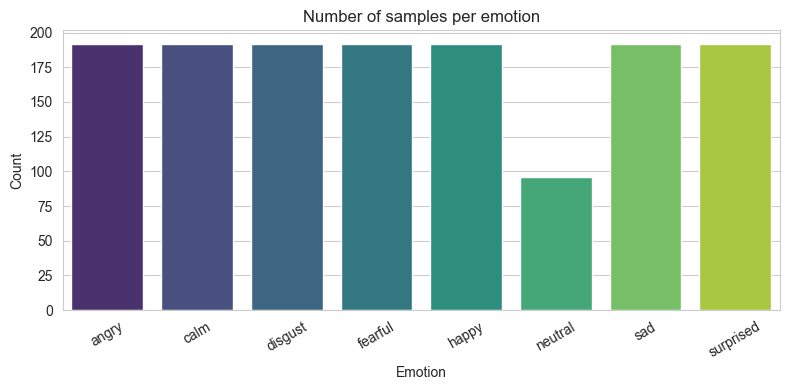

In [62]:
emotion_counts = df["emotion_label"].value_counts().sort_index()
print(emotion_counts)

plt.figure(figsize=(8, 4))
sns.barplot(x=emotion_counts.index, y=emotion_counts.values, palette="viridis")
plt.title("Number of samples per emotion")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()


**Actor analysis**

Each emotion was recorded by 24 actors. We want to:

1. Confirm the per-actor distribution looks even (it should be roughly the same number of clips per actor).
2. Note that the *same speaker* may appear in both train and test sets if we do a random split. That's called **speaker leakage**: the model can memorize a speaker's voice rather than learn the emotion, which inflates test accuracy. We'll discuss how to mitigate this in the preprocessing section.

Samples per actor (first 10):
actor_id
01    60
02    60
03    60
04    60
05    60
06    60
07    60
08    60
09    60
10    60
Name: count, dtype: int64


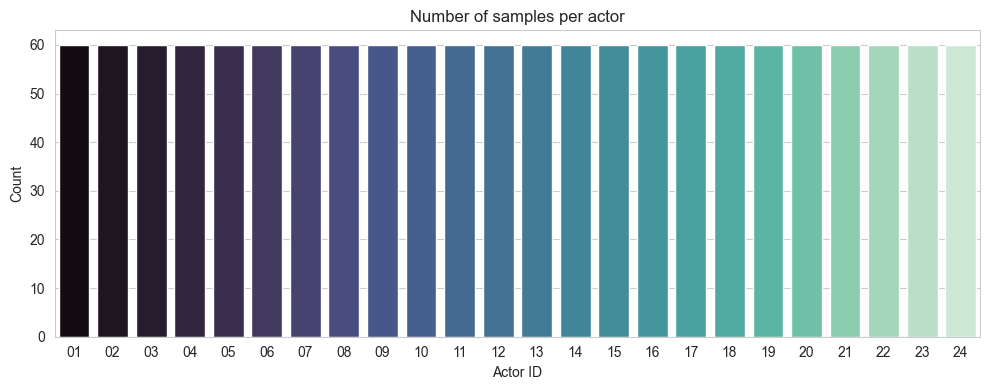

In [63]:
actor_counts = df["actor_id"].value_counts().sort_index()
print("Samples per actor (first 10):")
print(actor_counts.head(10))

plt.figure(figsize=(10, 4))
sns.barplot(x=actor_counts.index, y=actor_counts.values, palette="mako")
plt.title("Number of samples per actor")
plt.xlabel("Actor ID")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


**Audio duration analysis**

Different emotions might be expressed at different speeds (e.g., excited speech tends to be faster). We want to know how long clips are on average so we can:

- decide whether trimming/padding is needed for sequence models later,
- catch unusually short or long clips that might be noise.

In [64]:
# Compute the duration of every clip. This takes a few seconds on full RAVDESS.
durations = []
for p in df["file_path"]:
    try:
        # librosa.get_duration is much faster than loading the full waveform
        d = librosa.get_duration(path=p)
    except Exception:
        d = np.nan
    durations.append(d)

df["duration_sec"] = durations
print(df["duration_sec"].describe())


count    1440.000000
mean        3.700665
std         0.336676
min         2.936271
25%         3.470146
50%         3.670333
75%         3.870542
max         5.271937
Name: duration_sec, dtype: float64


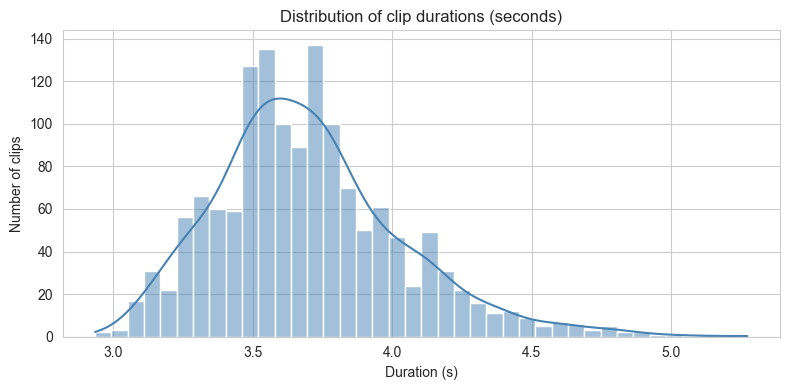

Shortest clips:
                                          file_path emotion_label  \
727  data/ravdess/Actor_13/03-01-02-01-02-02-13.wav          calm   
655  data/ravdess/Actor_11/03-01-08-01-02-02-11.wav     surprised   
730  data/ravdess/Actor_13/03-01-02-02-02-01-13.wav          calm   
731  data/ravdess/Actor_13/03-01-02-02-02-02-13.wav          calm   
775  data/ravdess/Actor_13/03-01-08-01-02-02-13.wav     surprised   

     duration_sec  
727      2.936271  
655      2.969625  
730      3.003000  
731      3.036354  
775      3.036375  

Longest clips:
                                           file_path emotion_label  \
1129  data/ravdess/Actor_19/03-01-07-02-01-02-19.wav       disgust   
1415  data/ravdess/Actor_24/03-01-05-02-02-02-24.wav         angry   
40    data/ravdess/Actor_01/03-01-06-02-01-01-01.wav       fearful   
1131  data/ravdess/Actor_19/03-01-07-02-02-02-19.wav       disgust   
1130  data/ravdess/Actor_19/03-01-07-02-02-01-19.wav       disgust   

      durati

In [65]:
plt.figure(figsize=(8, 4))
sns.histplot(df["duration_sec"].dropna(), bins=40, kde=True, color="steelblue")
plt.title("Distribution of clip durations (seconds)")
plt.xlabel("Duration (s)")
plt.ylabel("Number of clips")
plt.tight_layout()
plt.show()

print("Shortest clips:")
print(df.nsmallest(5, "duration_sec")[["file_path", "emotion_label", "duration_sec"]])
print("\nLongest clips:")
print(df.nlargest(5, "duration_sec")[["file_path", "emotion_label", "duration_sec"]])


**Sampling rate analysis**

The sampling rate is how many audio samples per second the file contains (e.g., 48,000 Hz). If different clips have different sampling rates, MFCC features extracted from them won't be comparable, because the frequency content is sampled at different resolutions. We confirm the rate is consistent across the dataset.

In [66]:
# Sample the first 100 files to keep this quick
sample = df.sample(min(100, len(df)), random_state=SEED)
rates = []
for p in sample["file_path"]:
    try:
        y, sr = librosa.load(p, sr=None, duration=0.1)
        rates.append(sr)
    except Exception:
        pass

print("Unique sampling rates observed in a 100-file sample:", set(rates))


Unique sampling rates observed in a 100-file sample: {48000}


RAVDESS uses **48,000 Hz** throughout. When we extract MFCCs we will downsample to **22,050 Hz** (librosa's default)

**Waveform visualization**

A waveform is just a plot of audio amplitude over time — it's the most "raw" view of a sound. Different emotions usually have different amplitude envelopes: angry speech often has bigger swings; sad speech tends to be quieter and more even. We plot one example per emotion to build intuition.

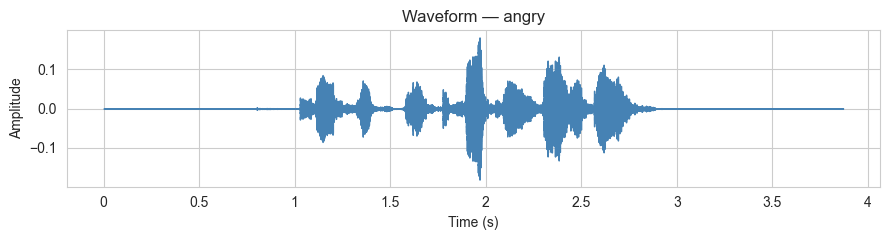

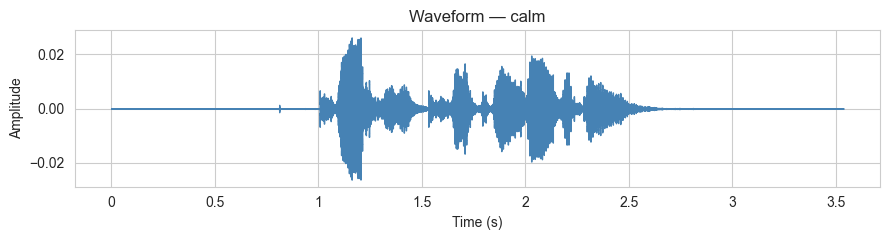

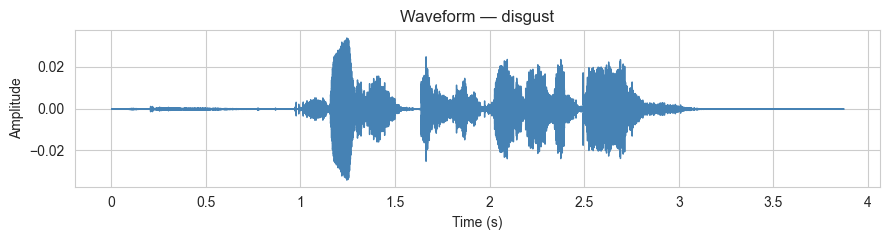

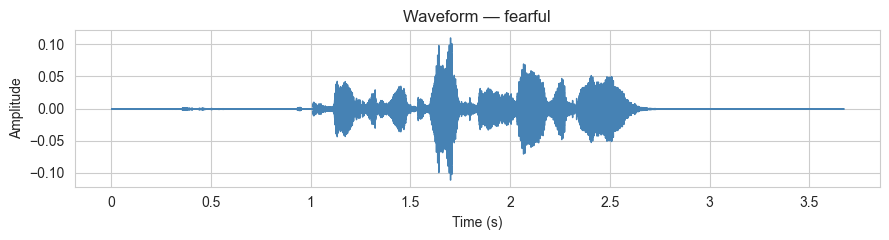

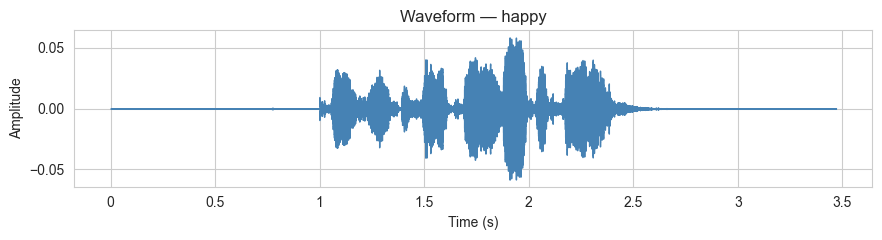

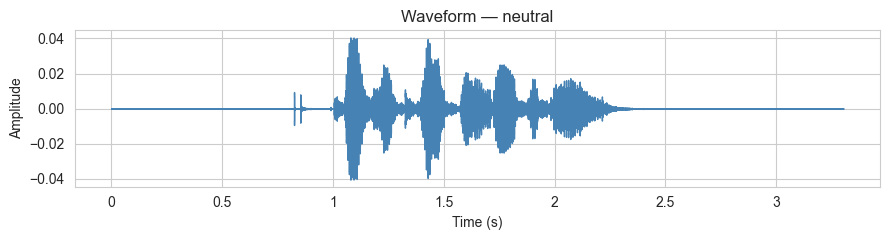

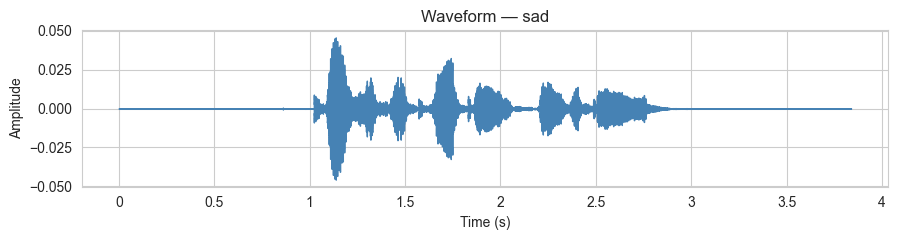

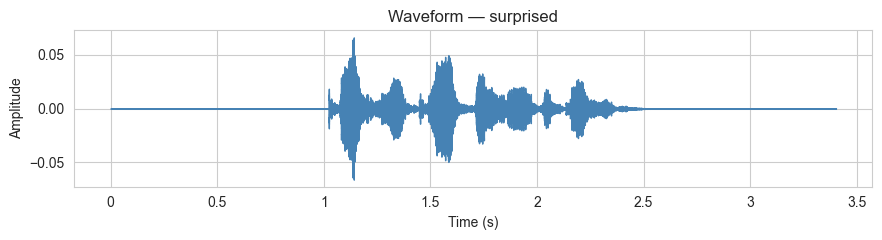

In [67]:
def plot_waveform(filepath, title):
    y, sr = librosa.load(filepath, sr=None)
    plt.figure(figsize=(9, 2.5))
    librosa.display.waveshow(y, sr=sr, color="steelblue")
    plt.title(title)
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    plt.tight_layout()
    plt.show()

# One example clip per emotion
example_clips = df.groupby("emotion_label").first().reset_index()
for _, row in example_clips.iterrows():
    plot_waveform(row["file_path"], f"Waveform — {row['emotion_label']}")


**Spectrogram visualization**

A waveform shows amplitude over time, but it hides which **frequencies** are present. A spectrogram shows how energy is distributed across frequencies over time — it's basically a 2D heatmap where the x-axis is time, the y-axis is frequency, and color is intensity (in decibels). Speech recognition systems usually work on something like this rather than the raw waveform.

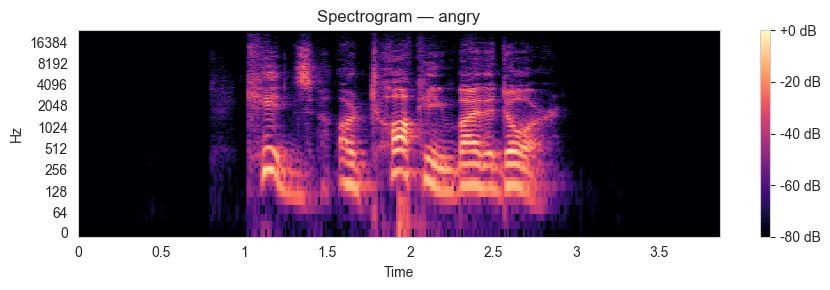

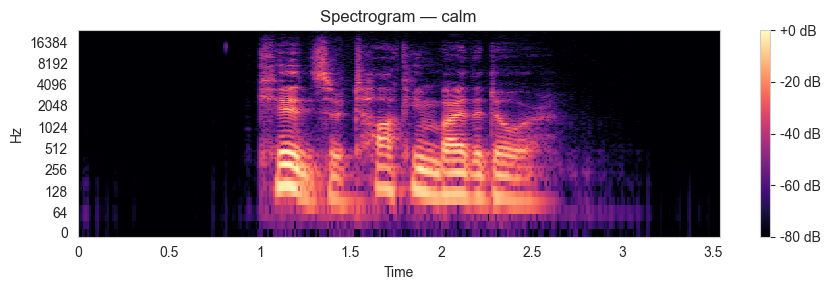

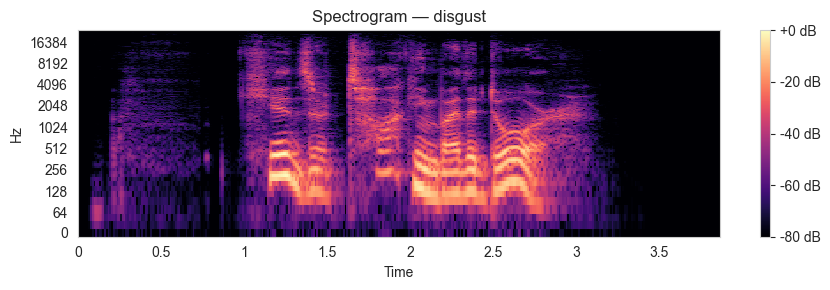

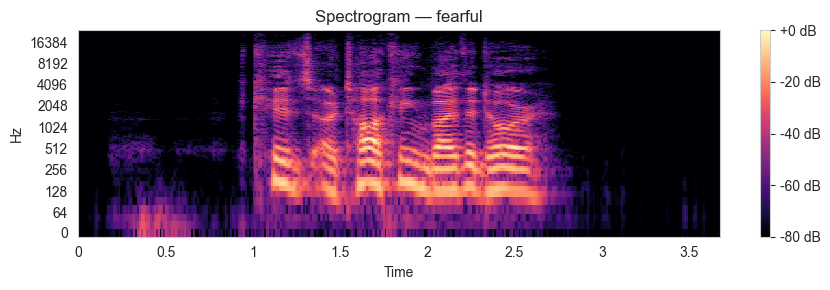

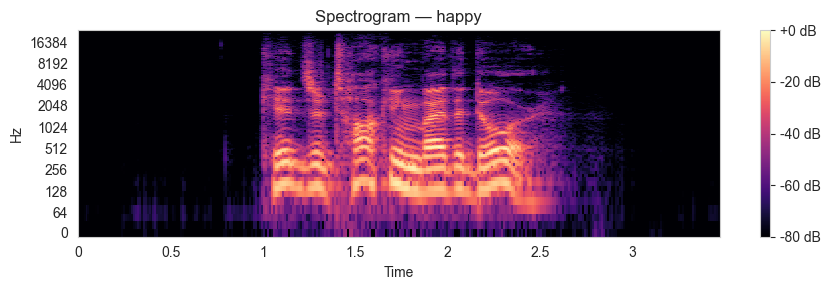

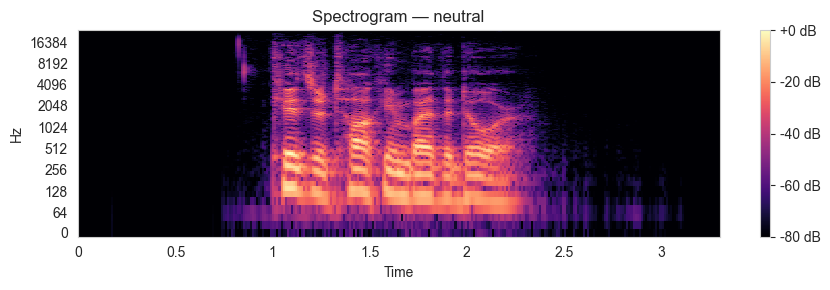

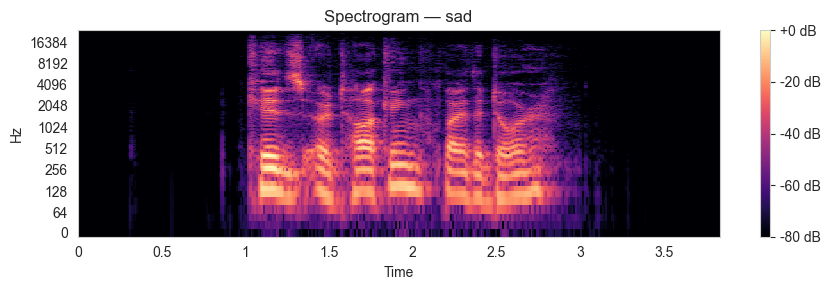

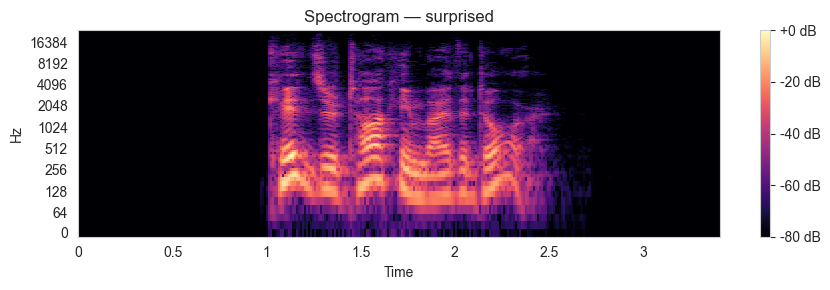

In [68]:
def plot_spectrogram(filepath, title):
    y, sr = librosa.load(filepath, sr=None)
    # Short-time Fourier transform, then convert magnitude to decibels
    S = np.abs(librosa.stft(y))
    S_db = librosa.amplitude_to_db(S, ref=np.max)

    plt.figure(figsize=(9, 3))
    librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="log", cmap="magma")
    plt.colorbar(format="%+2.0f dB")
    plt.title(title)
    plt.tight_layout()
    plt.show()

# Same example clips as above so we can compare to the waveforms
for _, row in example_clips.iterrows():
    plot_spectrogram(row["file_path"], f"Spectrogram — {row['emotion_label']}")


**MFCC visualization**

**MFCCs** (Mel-frequency cepstral coefficients) are a compact summary of the spectrogram that emphasizes the frequency bands the human ear is most sensitive to. They're the most common audio feature for speech tasks because they capture the *shape* of the spectrum (which encodes things like vowel sounds and emotional tone) without all the noise of the full spectrogram.

Below, each column is a short time frame, each row is one of 40 MFCC coefficients, and the color shows the value. Different emotions tend to produce visibly different MFCC patterns.

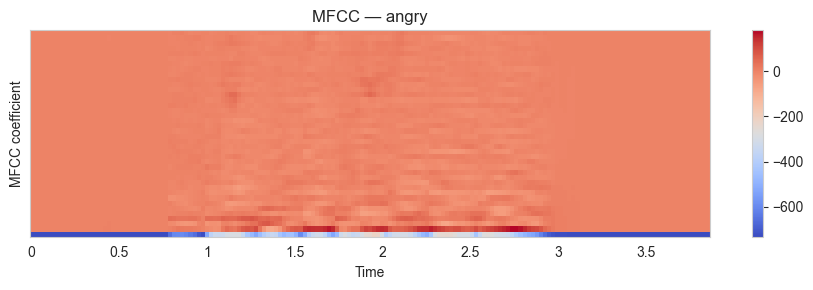

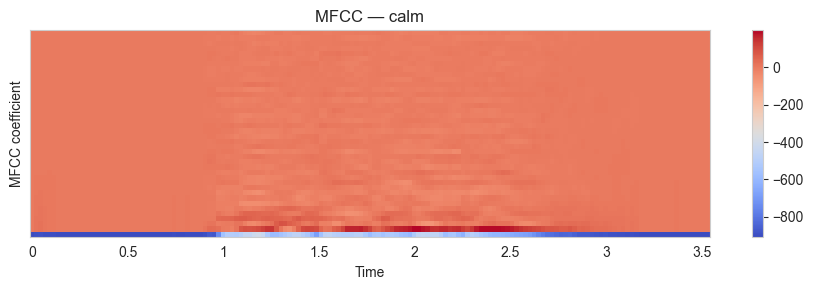

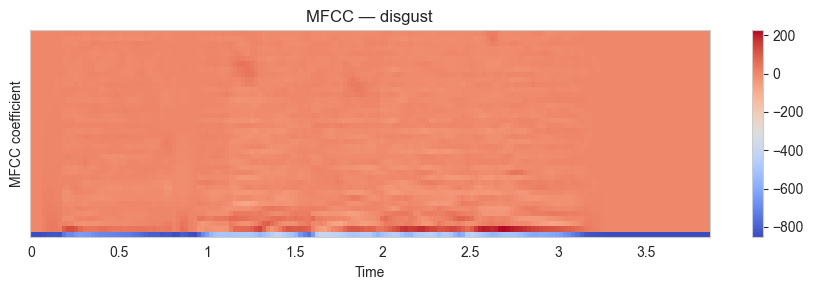

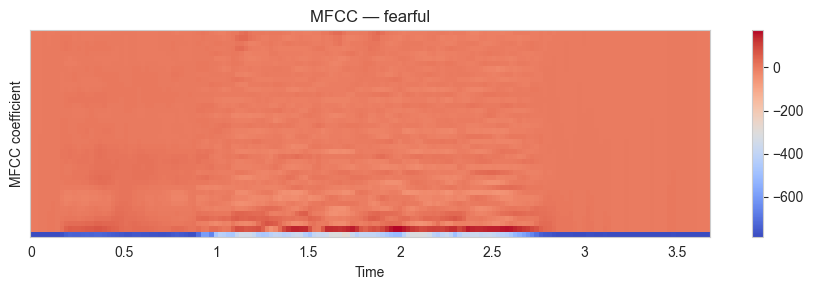

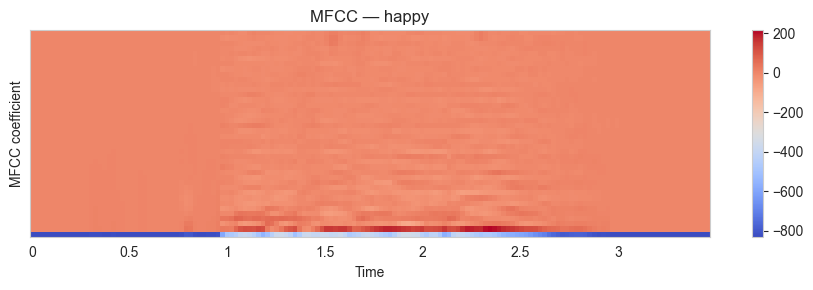

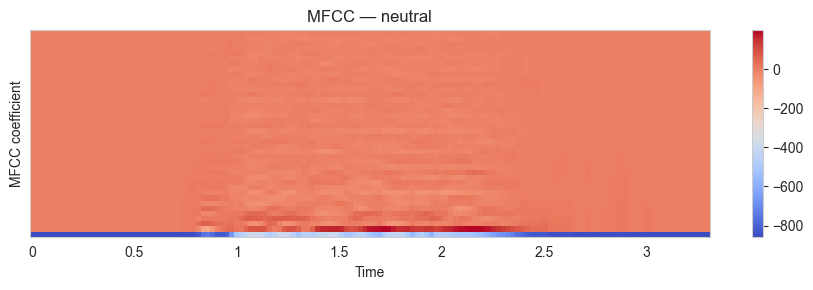

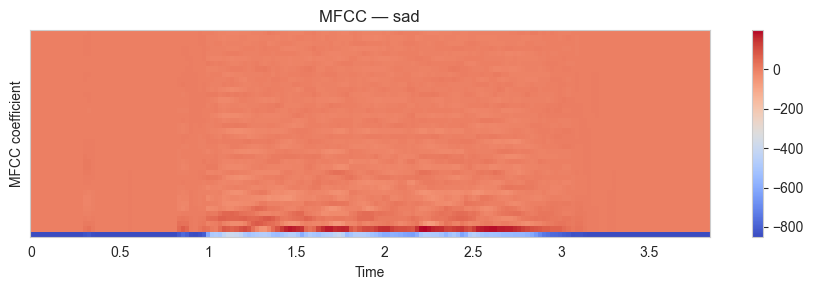

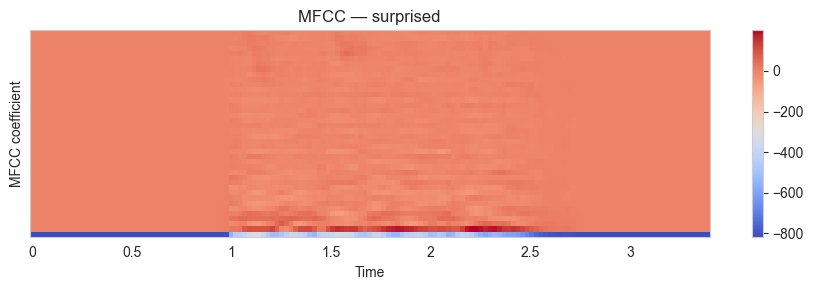

In [69]:
def plot_mfcc(filepath, title, n_mfcc=40):
    y, sr = librosa.load(filepath, sr=22050)
    mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
    plt.figure(figsize=(9, 3))
    librosa.display.specshow(mfccs, sr=sr, x_axis="time", cmap="coolwarm")
    plt.colorbar()
    plt.title(title)
    plt.ylabel("MFCC coefficient")
    plt.tight_layout()
    plt.show()

for _, row in example_clips.iterrows():
    plot_mfcc(row["file_path"], f"MFCC — {row['emotion_label']}")


**EDA summary**

**Class balance.** Seven emotions have 192 clips each; neutral has about half (96) because RAVDESS doesn't include a "strong" intensity version of it. I'll lean on macro F1 alongside accuracy so the smaller class isn't ignored.

**Actors.** All 24 actors contributed exactly 60 clips. The dataset is perfectly balanced at the speaker level

**Duration.** Clips are tightly clustered: mean ≈ 3.7s, standard deviation ≈ 0.34s, range ≈ 2.9–5.3s. Nothing unusually short or long, and the histogram is roughly bell-shaped.

**Sampling rate.** All files use the same rate, so MFCCs across clips are directly comparable.

**Waveforms.** Loud, expressive emotions like *angry* have noticeably bigger amplitude swings; *calm* and *disgust* look quieter and smoother. So there's already useful information in the raw signal envelope.

**Spectrograms.** I can see distinct horizontal bands (harmonic structure of the voice) and visibly different patterns across emotions — *angry* has more high-frequency energy, *calm* concentrates lower. This is the signal MFCCs are about to compress.

**MFCCs.** The first coefficient (very bottom row) dominates because it tracks overall energy, but the other coefficients show subtler differences between emotions.



**Feature extraction**

We now turn each audio clip into a fixed-length numerical vector that ML models can consume. The standard approach for a baseline is:

1. Load the audio with librosa.
2. Compute 40 MFCC coefficients across time (this gives a matrix of shape `(40, n_frames)`).
3. **Average the MFCCs across the time axis** to collapse the matrix into a single 40-dimensional vector.

> We average MFCCs across time because traditional machine learning models like Logistic Regression and Random Forests expect a *fixed-length* numerical input per sample. Audio clips have different lengths, so without this collapse step our feature vectors would have different shapes. Later, the LSTM/CNN-LSTM models will keep the time axis intact to exploit temporal information.

We wrap this in a function so we can call it cleanly for every file, and we wrap each call in a try/except so a single bad file doesn't crash the whole loop.

In [70]:
N_MFCC = 40           # number of MFCC coefficients
SAMPLE_RATE = 22050   # resample everything to this rate for consistency

def extract_mfcc_mean(filepath, n_mfcc=N_MFCC, sr=SAMPLE_RATE):
    """Load an audio file and return the time-averaged MFCC feature vector.

    Returns a 1-D numpy array of length n_mfcc, or None if the file fails to load.
    """
    try:
        y, _ = librosa.load(filepath, sr=sr)
        # mfccs has shape (n_mfcc, n_frames). Mean across axis=1 collapses time.
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=n_mfcc)
        mfccs_mean = np.mean(mfccs, axis=1)
        return mfccs_mean
    except Exception as e:
        print(f"Failed to extract from {filepath}: {e}")
        return None

# Quick smoke test on one file to confirm the function works
test_vec = extract_mfcc_mean(df["file_path"].iloc[0])
print("Feature vector shape:", test_vec.shape if test_vec is not None else None)
print("First 5 values:", test_vec[:5] if test_vec is not None else None)


Feature vector shape: (40,)
First 5 values: [-6.9779260e+02  5.4890041e+01  6.6346580e-01  1.2435786e+01
  7.7339525e+00]


Now we run this for every file in the cleaned dataframe. This is the slowest cell in the notebook (a few minutes on full RAVDESS), so we add a small progress indicator so it doesn't feel frozen.

In [71]:
features = []
labels = []
failed_paths = []

for i, row in df.iterrows():
    vec = extract_mfcc_mean(row["file_path"])
    if vec is None:
        failed_paths.append(row["file_path"])
        continue
    features.append(vec)
    labels.append(row["emotion_label"])
    if (i + 1) % 200 == 0:
        print(f"  processed {i + 1} / {len(df)} files")

X = np.array(features)
y = np.array(labels)
print(f"\nFinished. X shape: {X.shape}, y shape: {y.shape}")
print(f"Files that failed during feature extraction: {len(failed_paths)}")


  processed 200 / 1440 files
  processed 400 / 1440 files
  processed 600 / 1440 files
  processed 800 / 1440 files
  processed 1000 / 1440 files
  processed 1200 / 1440 files
  processed 1400 / 1440 files

Finished. X shape: (1440, 40), y shape: (1440,)
Files that failed during feature extraction: 0


In [72]:
# Final cleaning step we promised earlier: NaN / inf in feature values.
nan_mask = np.isnan(X).any(axis=1) | np.isinf(X).any(axis=1)
print(f"Rows with NaN or inf in features: {nan_mask.sum()}")

if nan_mask.any():
    X = X[~nan_mask]
    y = y[~nan_mask]
    print(f"After removing them: X shape: {X.shape}, y shape: {y.shape}")


Rows with NaN or inf in features: 0


Now that we have a feature matrix, let's revisit the **feature distribution** and **correlation** analyses from EDA. We turn `X` into a dataframe so plotting is easier.

In [73]:
mfcc_cols = [f"mfcc_{i}" for i in range(X.shape[1])]
feat_df = pd.DataFrame(X, columns=mfcc_cols)
feat_df["emotion_label"] = y
feat_df.head()


,mfcc_0,mfcc_1,mfcc_2,mfcc_3,mfcc_4,mfcc_5,mfcc_6,mfcc_7,mfcc_8,mfcc_9,...,mfcc_31,mfcc_32,mfcc_33,mfcc_34,mfcc_35,mfcc_36,mfcc_37,mfcc_38,mfcc_39,emotion_label
0,-697.792603,54.890041,0.663466,12.435786,7.733953,0.530750,-3.216630,-3.159395,-10.977551,-2.848710,...,-2.119634,-2.712589,-1.836127,-3.204805,-1.545369,-1.090937,-1.770106,-3.501132,-1.538087,neutral
1,-692.855774,55.363895,-1.548320,16.038307,8.818810,-0.146586,-1.373392,-5.293179,-11.623184,-1.348283,...,-2.677299,-2.143264,-2.461078,-3.019027,-0.804861,-1.290269,-3.086973,-3.209748,-2.307159,neutral
2,-691.587891,58.024662,0.159464,13.624650,5.374111,1.162337,-2.083360,-5.382585,-10.332823,-3.662082,...,-2.134345,-2.395041,-1.902938,-2.764431,-1.979178,-1.104503,-2.729538,-3.508906,-2.246375,neutral
3,-685.105469,55.879421,2.783262,13.252022,6.989669,2.981274,-1.586029,-6.961660,-10.348491,-3.270768,...,-2.166374,-2.881301,-2.769905,-3.236377,-1.457207,-0.953106,-2.450082,-3.419579,-3.367245,neutral
4,-727.104370,62.355034,3.121181,15.064671,8.132433,1.927085,-3.274657,-3.761792,-9.750298,-4.853837,...,-1.200894,-1.910600,-2.423685,-1.769383,-0.418556,-1.791784,-1.721065,-3.857929,-2.711536,calm


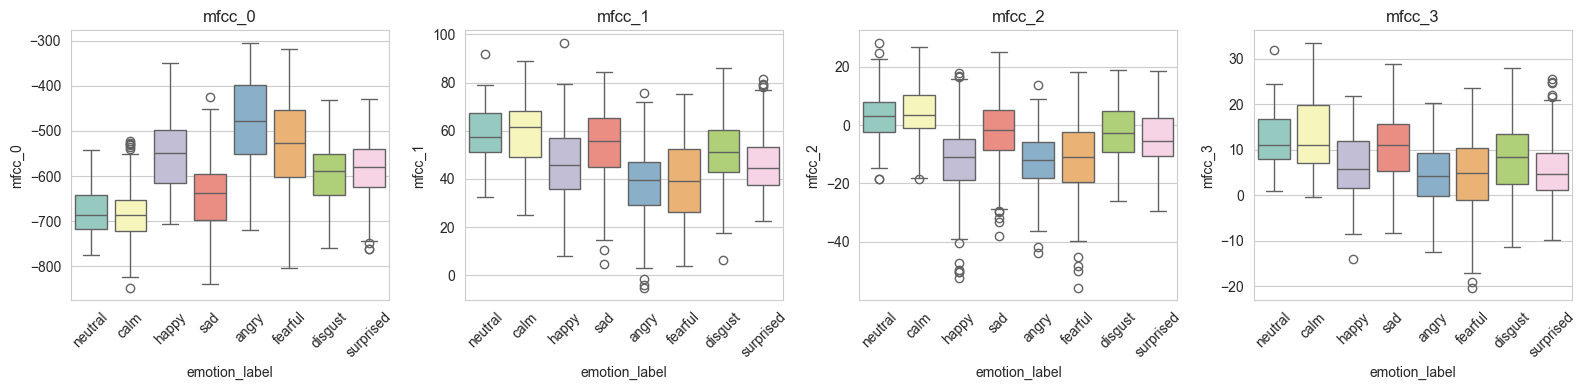

In [74]:
# Distribution of a few selected MFCCs across emotions.
# We pick the first few because they tend to carry the most energy.
selected = ["mfcc_0", "mfcc_1", "mfcc_2", "mfcc_3"]
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax, col in zip(axes, selected):
    sns.boxplot(data=feat_df, x="emotion_label", y=col, ax=ax, palette="Set3")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


**What we see.** Some MFCC coefficients (especially the first few) show clearly different distributions across emotions — for example, the means tend to shift for angry vs. sad. That's the signal our models will pick up on.

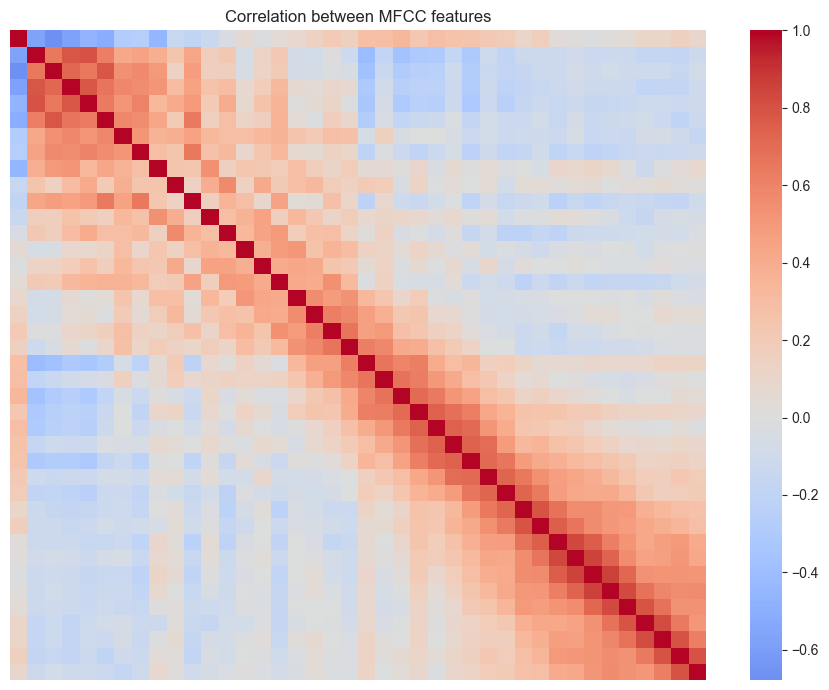

In [75]:
# Correlation heatmap among the 40 MFCC features.
plt.figure(figsize=(9, 7))
sns.heatmap(feat_df[mfcc_cols].corr(), cmap="coolwarm", center=0,
            xticklabels=False, yticklabels=False)
plt.title("Correlation between MFCC features")
plt.tight_layout()
plt.show()


**What we see.** There is moderate correlation between neighboring MFCCs (the bright diagonal stripe), which is expected: nearby coefficients describe similar parts of the cepstrum. There's no extreme redundancy though, so we will keep all 40 features.

**Preprocessing**

Three things happen before modeling:

1. **Encode the labels** from strings (`"angry"`, `"happy"`, …) to integers — most ML models and Keras' `sparse_categorical_crossentropy` expect integer labels.
2. **Split** into a training set (80%) and a test set (20%), with **stratification** so each emotion is represented in both splits in the same proportions.
3. **Scale the features** so each MFCC has mean 0 and standard deviation 1 — this helps Logistic Regression and neural networks converge much faster.



In [76]:
# Label encoding
le = LabelEncoder()
y_enc = le.fit_transform(y)

label_to_int = dict(zip(le.classes_, le.transform(le.classes_)))
int_to_label = {v: k for k, v in label_to_int.items()}
print("Label -> integer mapping:")
for lab, i in label_to_int.items():
    print(f"  {i}: {lab}")


Label -> integer mapping:
  0: angry
  1: calm
  2: disgust
  3: fearful
  4: happy
  5: neutral
  6: sad
  7: surprised


In [77]:
# Stratified 80/20 split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc,
    test_size=0.20,
    stratify=y_enc,    # keeps class proportions the same in train and test
    random_state=SEED,
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")

# Quick check that stratification worked
print("\nClass proportions in training set:")
print(pd.Series(y_train).value_counts(normalize=True).round(3).sort_index())
print("\nClass proportions in test set:")
print(pd.Series(y_test).value_counts(normalize=True).round(3).sort_index())


Train: (1152, 40), Test: (288, 40)

Class proportions in training set:
0    0.134
1    0.134
2    0.134
3    0.133
4    0.133
5    0.067
6    0.134
7    0.133
Name: proportion, dtype: float64

Class proportions in test set:
0    0.132
1    0.132
2    0.132
3    0.135
4    0.135
5    0.066
6    0.132
7    0.135
Name: proportion, dtype: float64


In [78]:
# Feature scaling (fit on train only!)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # learns mean/std from training
X_test_scaled = scaler.transform(X_test)         # applies them to test
print("Scaling complete. Mean of training features:", X_train_scaled.mean().round(4),
      "Std:", X_train_scaled.std().round(4))


Scaling complete. Mean of training features: 0.0 Std: 1.0


## **Baseline Model — traditional ML baseline**

We train **two** classical models and keep the better one as our "baseline":

- **Logistic Regression**
- **Random Forest**

We then evaluate both with:

- accuracy
- macro F1-score (better than accuracy when classes are slightly imbalanced)
- a full classification report (precision/recall/F1 per emotion)
- a confusion matrix (which emotions get confused with which)

In [79]:
# Logistic Regression
log_reg = LogisticRegression(
    max_iter=2000,
    multi_class="multinomial",
    solver="lbfgs",
    random_state=SEED,
)
log_reg.fit(X_train_scaled, y_train)

y_pred_lr = log_reg.predict(X_test_scaled)
acc_lr = accuracy_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr, average="macro")
print(f"Logistic Regression — accuracy: {acc_lr:.4f}, macro F1: {f1_lr:.4f}")


Logistic Regression — accuracy: 0.4271, macro F1: 0.4094


In [80]:
# Random Forest
rf = RandomForestClassifier(
    n_estimators=300,
    random_state=SEED,
    n_jobs=-1,
)
rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)
acc_rf = accuracy_score(y_test, y_pred_rf)
f1_rf = f1_score(y_test, y_pred_rf, average="macro")
print(f"Random Forest        — accuracy: {acc_rf:.4f}, macro F1: {f1_rf:.4f}")


Random Forest        — accuracy: 0.5868, macro F1: 0.5472


In [81]:
if f1_rf >= f1_lr:
    baseline_name = "Random Forest"
    baseline_model = rf
    y_pred_baseline = y_pred_rf
    acc_baseline = acc_rf
    f1_baseline = f1_rf
else:
    baseline_name = "Logistic Regression"
    baseline_model = log_reg
    y_pred_baseline = y_pred_lr
    acc_baseline = acc_lr
    f1_baseline = f1_lr

print(f"Selected baseline: {baseline_name}")
print(f"  Accuracy: {acc_baseline:.4f}")
print(f"  Macro F1: {f1_baseline:.4f}")


Selected baseline: Random Forest
  Accuracy: 0.5868
  Macro F1: 0.5472


Random Forest clearly outperforms Logistic Regression on both metrics — about 16 points higher on accuracy (0.59 vs. 0.43) and 14 points higher on macro F1 (0.55 vs. 0.41).

we keep **Random Forest as my official baseline** and use it as the bar the deep learning model needs to beat.

In [82]:
# Full classification report for the chosen baseline
print(f"Classification report — {baseline_name}\n")
print(classification_report(y_test, y_pred_baseline, target_names=le.classes_))


Classification report — Random Forest

              precision    recall  f1-score   support

       angry       0.75      0.71      0.73        38
        calm       0.59      0.92      0.72        38
     disgust       0.52      0.63      0.57        38
     fearful       0.60      0.72      0.65        39
       happy       0.61      0.36      0.45        39
     neutral       0.38      0.16      0.22        19
         sad       0.52      0.39      0.45        38
   surprised       0.57      0.59      0.58        39

    accuracy                           0.59       288
   macro avg       0.57      0.56      0.55       288
weighted avg       0.58      0.59      0.57       288



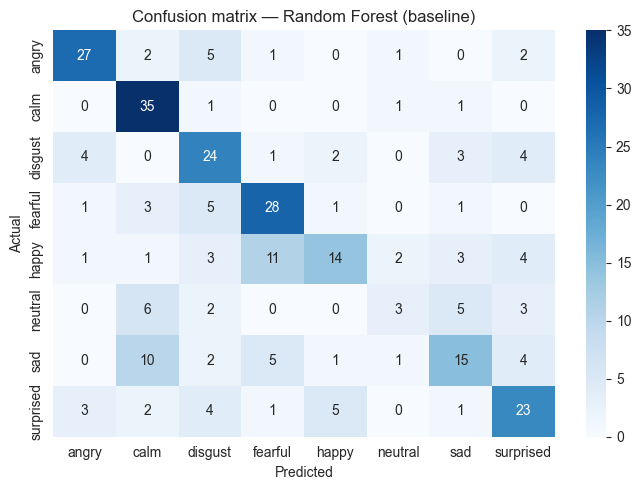

In [83]:
# Confusion matrix for the chosen baseline
cm_baseline = confusion_matrix(y_test, y_pred_baseline)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_baseline, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title(f"Confusion matrix — {baseline_name} (baseline)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


##  Model 1 — Dense Neural Network (MLP)



In [84]:
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import BatchNormalization, Activation
from tensorflow.keras.optimizers import Adam

input_dim = X_train_scaled.shape[1]   # 40 MFCC features
num_classes = len(le.classes_)        # 8 emotions

model = Sequential([
    Input(shape=(input_dim,)),

    Dense(128, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.4),

    Dense(64, kernel_regularizer=l2(1e-4)),
    BatchNormalization(),
    Activation("relu"),
    Dropout(0.4),

    Dense(num_classes, activation="softmax"),
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         5,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,792 (57.78 KB)

 Trainable params: 14,408 (56.28 KB)

 Non-trainable params: 384 (1.50 KB)

In [85]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=80,
    batch_size=32,
    callbacks=[early_stop],
    verbose=2,
)

Epoch 1/80
29/29 - 1s - 33ms/step - accuracy: 0.1466 - loss: 2.4967 - val_accuracy: 0.2424 - val_loss: 2.0581
Epoch 2/80
29/29 - 0s - 1ms/step - accuracy: 0.2182 - loss: 2.1894 - val_accuracy: 0.2727 - val_loss: 1.9391
Epoch 3/80
29/29 - 0s - 1ms/step - accuracy: 0.2443 - loss: 2.0319 - val_accuracy: 0.2944 - val_loss: 1.8758
Epoch 4/80
29/29 - 0s - 1ms/step - accuracy: 0.2986 - loss: 1.9221 - val_accuracy: 0.3160 - val_loss: 1.8189
Epoch 5/80
29/29 - 0s - 1ms/step - accuracy: 0.3214 - loss: 1.8352 - val_accuracy: 0.3377 - val_loss: 1.7880
Epoch 6/80
29/29 - 0s - 2ms/step - accuracy: 0.3301 - loss: 1.8157 - val_accuracy: 0.3463 - val_loss: 1.7524
Epoch 7/80
29/29 - 0s - 2ms/step - accuracy: 0.3366 - loss: 1.7826 - val_accuracy: 0.3680 - val_loss: 1.7098
Epoch 8/80
29/29 - 0s - 2ms/step - accuracy: 0.3626 - loss: 1.6992 - val_accuracy: 0.3636 - val_loss: 1.6785
Epoch 9/80
29/29 - 0s - 1ms/step - accuracy: 0.3909 - loss: 1.6502 - val_accuracy: 0.3853 - val_loss: 1.6510
Epoch 10/80
29/29 

**Evaluate the deep learning model**

We plot the four training curves (training/validation accuracy and loss) to **see** overfitting rather than just measure it. If the training curve keeps improving while the validation curve stalls, that's overfitting.

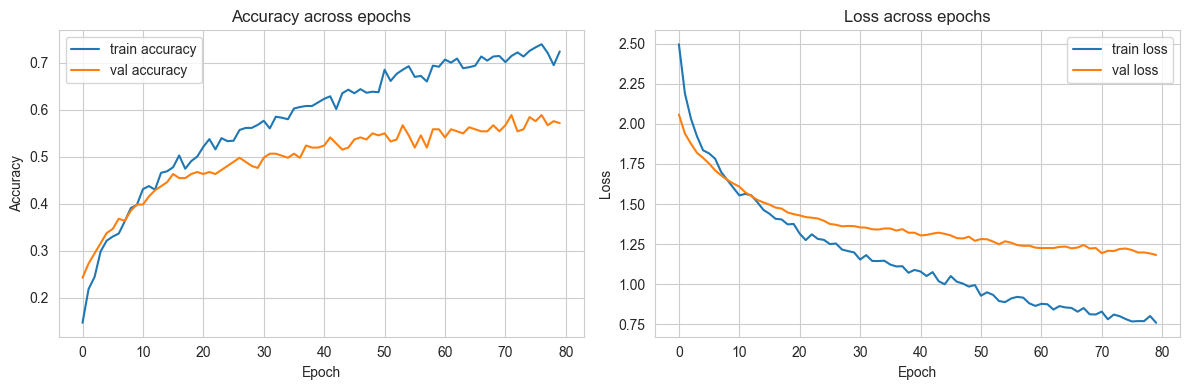

In [86]:
hist = history.history

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist["accuracy"], label="train accuracy")
axes[0].plot(hist["val_accuracy"], label="val accuracy")
axes[0].set_title("Accuracy across epochs")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

axes[1].plot(hist["loss"], label="train loss")
axes[1].plot(hist["val_loss"], label="val loss")
axes[1].set_title("Loss across epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


In [87]:
# Test-set evaluation
test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
y_pred_nn_probs = model.predict(X_test_scaled, verbose=0)
y_pred_nn = np.argmax(y_pred_nn_probs, axis=1)

f1_nn = f1_score(y_test, y_pred_nn, average="macro")
print(f"Dense NN — test accuracy: {test_acc:.4f}, macro F1: {f1_nn:.4f}")


Dense NN — test accuracy: 0.5660, macro F1: 0.5473


In [88]:
print("Classification report — Dense Neural Network\n")
print(classification_report(y_test, y_pred_nn, target_names=le.classes_))


Classification report — Dense Neural Network

              precision    recall  f1-score   support

       angry       0.68      0.71      0.69        38
        calm       0.55      0.68      0.61        38
     disgust       0.57      0.61      0.59        38
     fearful       0.52      0.69      0.59        39
       happy       0.67      0.36      0.47        39
     neutral       0.33      0.42      0.37        19
         sad       0.54      0.34      0.42        38
   surprised       0.62      0.64      0.63        39

    accuracy                           0.57       288
   macro avg       0.56      0.56      0.55       288
weighted avg       0.58      0.57      0.56       288



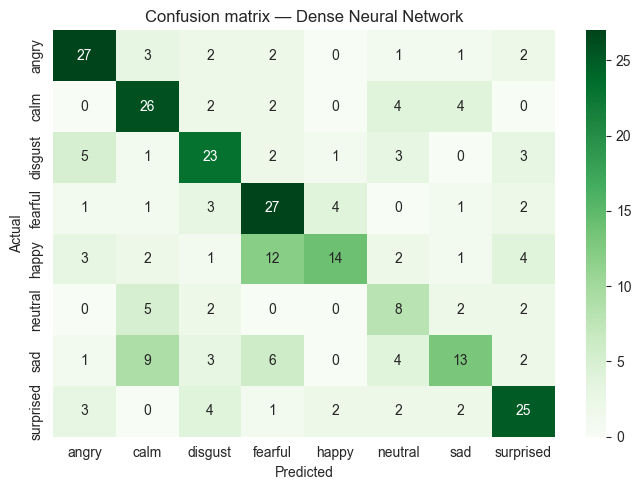

In [89]:
cm_nn = confusion_matrix(y_test, y_pred_nn)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_nn, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title("Confusion matrix — Dense Neural Network")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()


**Model comparison**



In [90]:
comparison = pd.DataFrame([
    {
        "model": baseline_name + " (baseline)",
        "test_accuracy": round(acc_baseline, 4),
        "macro_f1": round(f1_baseline, 4),

    },
    {
        "model": "Dense Neural Network (MLP)",
        "test_accuracy": round(test_acc, 4),
        "macro_f1": round(f1_nn, 4),

    },
])
comparison


,model,test_accuracy,macro_f1
0,Random Forest (baseline),0.5868,0.5472
1,Dense Neural Network (MLP),0.5660,0.5473
